In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [136]:
df_ap = pd.read_csv(r'final_report_AAPL.csv')
df_ms = pd.read_csv(r'final_report_MSFT.csv')
df_ts = pd.read_csv(r'final_report_TSLA.csv')
df_ap

,PositionQuantity,AvgPrice,Return,Capital,TimeStamp,MarketPrice
0,0.0,0.000000,0.0,105201.33,2026-03-10 13:32:00+00:00,259.740
1,0.0,0.000000,0.0,105201.33,2026-03-10 13:33:00+00:00,259.150
2,0.0,0.000000,0.0,105201.33,2026-03-10 13:34:00+00:00,259.405
3,0.0,0.000000,0.0,105201.33,2026-03-10 13:35:00+00:00,259.070
4,0.0,0.000000,0.0,105201.33,2026-03-10 13:36:00+00:00,259.190
...,...,...,...,...,...,...
478,56.0,255.705962,0.0,14206.52,2026-03-13 13:48:00+00:00,256.050
479,56.0,255.705962,0.0,14206.52,2026-03-13 13:49:00+00:00,255.990
480,56.0,255.705962,0.0,14206.52,2026-03-13 13:50:00+00:00,255.740
481,56.0,255.705962,0.0,14206.52,2026-03-13 13:51:00+00:00,255.630


### 1. Total Return

In [139]:
def process_df(df): 
    df['return'] = df['PositionQuantity'] * df['MarketPrice']
    df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], errors='coerce')
    df['TimeStamp'] = df['TimeStamp'].dt.tz_convert('US/Eastern')
    df['Absolute_Return'] = df['return'] + df['Capital'] - 100000
    df['Periodic_Return'] = df['Absolute_Return'] / 100000
    return df

In [141]:
df_ap_cln = process_df(df_ap)
df_ms_cln = process_df(df_ms)
df_ts_cln = process_df(df_ts)

In [147]:
total_return = df_ap_cln.iloc[-1, -1]
print('Total Return: ', total_return)

Total Return:  -0.7147708


### 2. Periodic Return

In [183]:
def plot(df, symbol):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(df.index, df['Periodic_Return'], color='tab:blue', marker='o', linewidth=2, label='Periodic_Return')
    ax2 = ax1.twinx()
    ax2.plot(df.index, df['MarketPrice'], color='tab:red', marker='s', linestyle='--', linewidth=2, label='Market_Price')
    
    ax1.set_xlabel('Timeline')
    ax1.set_ylabel('Periodic_Return', color='tab:blue')
    ax2.set_ylabel('Market_Price', color='tab:red')
    ax1.set_title(f'Periodic Return vs Market Price\n{symbol}')
    
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper left',bbox_to_anchor=(0, 0.95))
    
    plt.tight_layout()
    plt.show()
    return fig

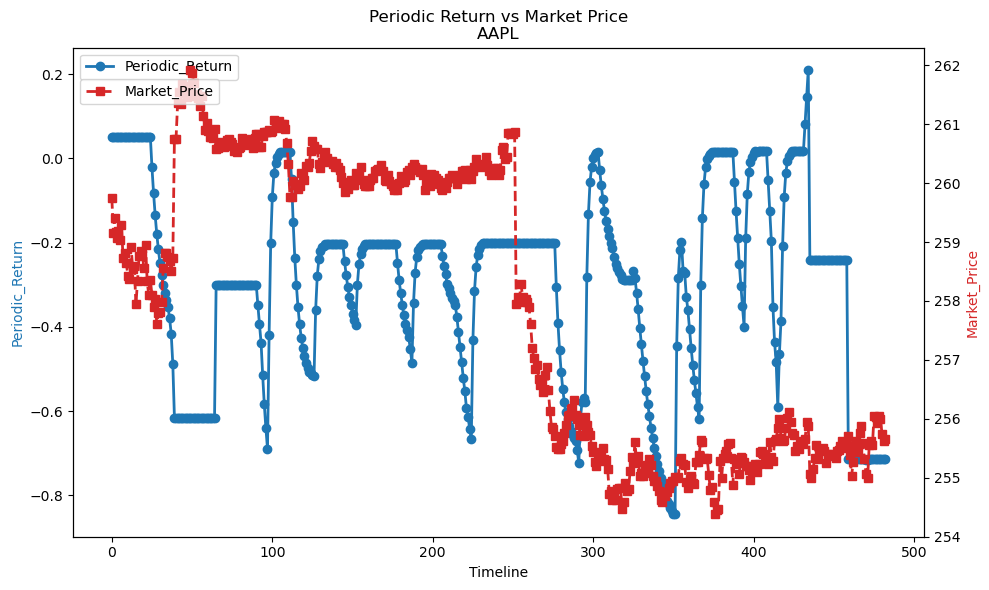

In [187]:
fig_1 = plot(df_ap_cln, 'AAPL')

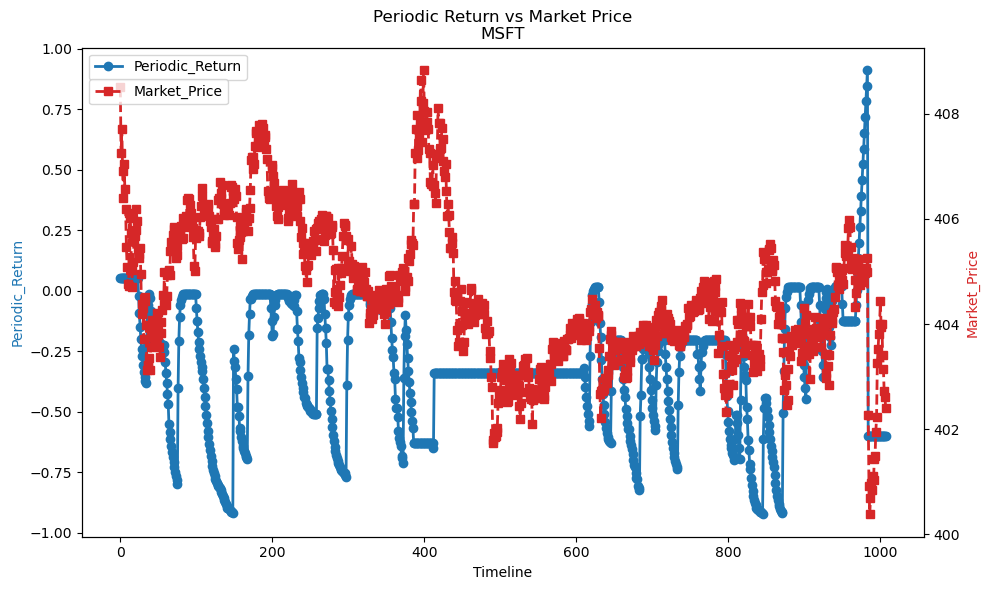

In [189]:
fig_2 = plot(df_ms_cln, 'MSFT')

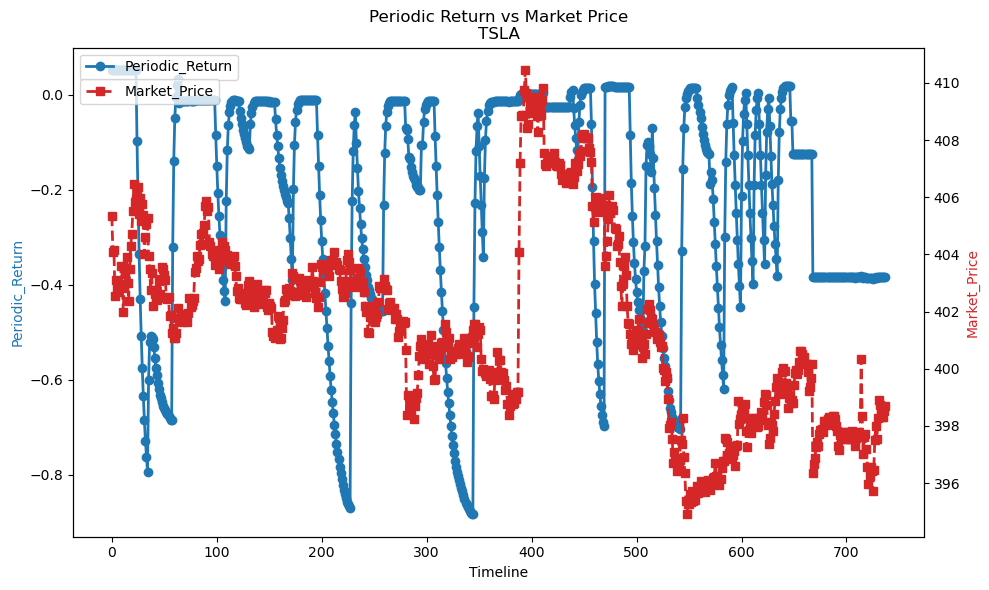

In [191]:
fig_3 = plot(df_ts_cln, 'TSLA')

### 3. Sharpe Ratio

#### To compare, we took 2025 180 days U.S. Treasury Bill return, which is close to 0.0417 as proxy of risk free rate. 

#### In addition, the Algo didn't start to run until the 25th data point, therefore, we tried to use df.iloc[25:, -1] to calculate return volatility. 

In [174]:
sharpe_ratio = (total_return - 0.0417) / df_ap_cln.iloc[25:, -1].std()
print('Sharpe Ratio: ', sharpe_ratio)

Sharpe Ratio:  -3.3876464766281846


### 4. Maximum Drawdown

In [176]:
mdd = (df_ap_cln.iloc[-100:, -1].max() - df_ap_cln.iloc[-100:, -1].min()) / df_ap_cln.iloc[-100:, -1].max()
print('Maximum Drawdown: ', mdd)

Maximum Drawdown:  4.400735841331419


### 5. Generate md File

In [193]:
plot_filename = "TrendingPerformance_AAPL.png"
fig_1.savefig(plot_filename, bbox_inches='tight')

df_markdown = df_ap.to_markdown(index=False)

intro_text = "# Group1 Report\n\nIn this Algo, we implemented momentum trading strategy combined with Moving Average Crossover strategy, along with the loss stop rate to be 0.03 and risk to be 15% of current capital to control the risk."
content_text = "\n\n## Multiprocessing\n\nIn this trading strategy, we've implemented 3 processes to run three symbol trading in parallel. Within each process, we run the engine per minute and store the most recent market price, ADX and RSI into local thread storage to realize multiprocessing and memory independency. \n\n## Momentum Strategy\n\nIn the Momentum Strategy, we used minute as trading interval and 15 days as window to calculate ADX and RSI.\n\n## Moving Average Crossover Strategy\n\nIn Moving Average Crossover Strategy, we used 5 datapoints as slow period and 25 datapoints as fast period.\n\n## Risk Control\n\nIn addition to the 0.03 loss stop, we've also conducted the simple average of the suggested position sizing from both Momentum strategy and Moving Average Crossover strategy to avoid skewed jump or drop from single algorithm."

In [195]:
markdown_filename = "performance.md"

with open(markdown_filename, "wt") as md_file:
    md_file.write(intro_text)
    md_file.write(content_text)
    md_file.write("\n\n# Performance Report\n\n")
    md_file.write("## Metrics Table\n\n")
    md_file.write(df_markdown)
    md_file.write("\n\n## Trending Performance Plot\n\n")
    md_file.write(f"![{plot_filename}]({plot_filename})\n")

### 6. Generate FutureImprovements.md

In [205]:
read_me = "# README\n\n## Future Improvement\n\nIn this competition, we've encountered two issues that could be improved in the future. \n    (1) On the first day, some of our code didn't work perfectly with API. So we used first dya to debug. In the future, such foreward testing could be done before real time implementation. \n    (2) Our Alpaca paper trading account was locked on Thursday, leading us unable to liquidate our positions or make new orders. After investigating the issues, we believe that this is caused by the race condition that first makes the orders pending and then lead to a internal lock in api. This could be due to either the trade interval is too short or connection lag. We could expand the trading interval and also add logic to place new order only when the old order is completed to solve this problem in the future.\n\n## Python Version\n\nIn the python file, we've used Numpy == 2.4.1 and Pandas == 2.3.3.\n\n## Parameters\n\nWe've put the parameters in main.py so that each aspects can be modified accordingly.\n\n## Execution\n\nTo run the whole Algorithm, please put all python file under the same folder directory, make sure the Numpy and Pandas version are correct and then run the main.py. \nmain.py will run the algo and save the results into 'final_report.csv', then using performance.ipynb will generate the performance md file report."

In [207]:
markdown_filename = "FutureImprovement.md"

with open(markdown_filename, "wt") as md_file:
    md_file.write(read_me)